# Generator-level event displays

Single simulated events from four corners of the 2018 signal grid, drawn
directly from the generator record (`GenPart`) of one ntuple file per sample.
**No selections of any kind are applied** -- no trigger, no reconstruction, no
kinematic cuts; the event shown is chosen by the deterministic rule described
below, not by hand.

Each figure has two panels:

- **Left ($\eta$-$\phi$):** the two dark photons (stars) with the
  $\Delta R = 0.4$ lepton-jet clustering cone drawn around each (dashed
  circle), and their daughter leptons (circles: muons; squares: electrons;
  marker area grows with $p_T$). This panel shows the collimation -- both
  daughters of a dark photon sit inside one clustering cone -- and the
  back-to-back topology, $\Delta\phi(Z_d, Z_d) \approx \pi$.
- **Right ($R$-$z$):** the same event in the longitudinal view. Each dark
  photon flies from its production vertex (the bound-state decay point,
  black dot -- drawn at its true $z$, which the beamspot spreads by
  centimeters) to its decay vertex (star); the dashed segment spans a
  transverse displacement $l_{xy}$, computed decay-minus-production, and
  the daughter leptons emerge as straight rays from the decay vertex. Gray
  lines mark the tracker outer radius ($r = 110$ cm, $|z| = 280$ cm) and
  the start of the muon system where the axis range reaches them. Rays are
  drawn without magnetic-field curvature: at the lepton $p_T$ shown here
  the bending radius is several to tens of meters, far larger than the
  tracker.

**Event choice rule:** among the first file's events in which every signal
lepton has $|\eta| < 2.4$, take the event whose larger dark-photon $l_{xy}$
is closest to the sample median of that quantity -- a typical event, not a
tail event.

The four samples step through one decade of displacement each while also
scanning the collimation:

| sample | $\langle l_{xy}\rangle$ scale | what it illustrates |
|---|---|---|
| `2Mu2E_500GeV_1p2GeV_0p019mm` | ~0.4 cm | boosted, nearly prompt: tight $\mu$-jet back-to-back with a tight $e$-jet |
| `4Mu_200GeV_1p2GeV_0p48mm` | ~4 cm | the sweet spot: collimated pairs, vertices beyond the beampipe, inside the pixels |
| `4Mu_1000GeV_0p25GeV_0p2mm` | ~20 cm | extreme collimation, $\Delta R \sim 10^{-3}$, mid-tracker vertices |
| `2Mu2E_100GeV_5p0GeV_200mm` | ~1 m | wide pairs near the cone size, decays reaching beyond the tracker in the tail |

In [1]:
import os
import sys

import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle
from coffea.nanoevents import NanoEventsFactory

here = os.getcwd()
repo = here.split("/sidm")[0]
for p in (repo, os.path.join(repo, "sidm", "studies", "truth_kinematics_forAN")):
    if p not in sys.path:
        sys.path.insert(1, p)
from sidm.tools import utilities, llpnanoaodschema
import _anatomy_lib as lib
import an_style

an_style.set_style()

def dphi(a, b):
    return np.mod(a - b + np.pi, 2 * np.pi) - np.pi

def first_file(sample, location_cfg):
    '''Resolve the first ntuple file of a sample from the location YAML.'''
    fs = utilities.make_fileset([sample], "llpNanoAOD_v2", max_files=1,
                                location_cfg=location_cfg, replace_xcache=True)
    files = fs[sample]
    if isinstance(files, dict):
        files = files.get("files", files)
    if isinstance(files, dict):
        files = list(files)
    return list(files)[0]

def load_dark_photons(sample, location_cfg):
    '''One file's dark photons, split by daughter flavor, decayed ones only.'''
    fname = first_file(sample, location_cfg)
    evts = NanoEventsFactory.from_root(
        fname + ":Events", schemaclass=llpnanoaodschema.LLPNanoAODSchema).events()
    gens = evts.GenPart
    genAs = gens[abs(gens.pdgId) == 32]
    out = {}
    for flav, pdg in [("mu", 13), ("e", 11)]:
        col = genAs[ak.all(abs(genAs.children.pdgId) == pdg, axis=-1)]
        out[flav] = col[ak.num(col.children, axis=2) >= 2]
    return out

def pick_event(As):
    '''Deterministic representative event: all daughters |eta| < 2.4, larger
    dark-photon lxy closest to the sample median of that quantity.'''
    ok = None
    lxy_parts = []
    for col in As.values():
        ch = col.children
        ok_f = ak.all(ak.all(abs(ch.eta) < 2.4, axis=2), axis=1)
        ok = ok_f if ok is None else (ok & ok_f)
        lxy_parts.append(np.sqrt((ch.vx[:, :, 0] - col.vx) ** 2
                                 + (ch.vy[:, :, 0] - col.vy) ** 2))
    max_lxy = ak.max(ak.concatenate(lxy_parts, axis=1), axis=1).to_numpy()
    ok = ok.to_numpy()
    if not ok.any():
        ok = np.ones_like(ok, dtype=bool)
    med = np.median(max_lxy[ok])
    return int(np.argmin(np.where(ok, abs(max_lxy - med), np.inf))), float(med)

def event_record(As, idx):
    '''Plain-number record of one event: per dark photon, its kinematics,
    production and decay vertices (lxy = decay minus production, the
    framework convention), and daughters.'''
    rec = []
    for flav, col in As.items():
        ch = col.children[idx]
        one = col[idx]
        for i in range(len(one)):
            px, py, pz = (float(one.vx[i]), float(one.vy[i]), float(one.vz[i]))
            dx, dy, dz = (float(ch.vx[i][0]), float(ch.vy[i][0]), float(ch.vz[i][0]))
            rec.append({
                "flavor": flav,
                "eta": float(one.eta[i]), "phi": float(one.phi[i]),
                "pt": float(one.pt[i]), "mass": float(one.mass[i]),
                "prod_z": pz, "prod_R": float(np.hypot(px, py)),
                "dec_z": dz, "dec_R": float(np.hypot(dx, dy)),
                "lxy": float(np.hypot(dx - px, dy - py)),
                "daughters": [
                    {"pt": float(ch.pt[i][j]), "eta": float(ch.eta[i][j]),
                     "phi": float(ch.phi[i][j])} for j in range(len(ch.pt[i]))],
            })
    return rec

/tmp/ipykernel_1764544/2126150309.py:9: DeprecationWarning: NanoEventsFactory.from_root() behavior has changed.
    The default behavior is that now it reads the input root file using
    the newly developed virtual arrays backend of awkward instead of dask.
    The backend choice is controlled by the `mode` argument of the method
    which can be set to "eager", "virtual", or "dask".
    The new default is "virtual" while the `delayed` argument has been removed.
    The old `delayed=True` is now equivalent to `mode="dask"`.
    The old `delayed=False` is now equivalent to `mode="eager"`.
    
  from coffea.nanoevents import NanoEventsFactory


In [2]:
FLAV_STYLE = {"mu": dict(color="#0072B2", marker="o", label=r"$\mu$"),
              "e":  dict(color="#D55E00", marker="s", label=r"$e$")}

def draw_etaphi(ax, rec):
    for a in rec:
        st = FLAV_STYLE[a["flavor"]]
        ax.add_patch(Circle((a["eta"], a["phi"]), 0.4, fill=False, ls="--",
                            color=st["color"], alpha=0.6))
        ax.plot(a["eta"], a["phi"], marker="*", ms=15, color=st["color"],
                mec="black", mew=0.5, ls="none")
        for d in a["daughters"]:
            ax.plot(d["eta"], d["phi"], marker=st["marker"],
                    ms=min(5 + 2.5 * np.sqrt(d["pt"]), 22), color=st["color"],
                    alpha=0.65, mec="black", mew=0.5, ls="none")
        d0, d1 = a["daughters"][0], a["daughters"][1]
        dr = np.hypot(d0["eta"] - d1["eta"], dphi(d0["phi"], d1["phi"]))
        lep = r"\mu" if a["flavor"] == "mu" else "e"
        ax.annotate(rf"$Z_d \to {lep}{lep}$" "\n"
                    rf"$p_T$ = {a['pt']:.0f} GeV" "\n"
                    rf"$\Delta R$ = {dr:.3g}",
                    (a["eta"], a["phi"]), textcoords="offset points",
                    xytext=(14, 14), fontsize=11)
    flavors = {a["flavor"] for a in rec}
    handles = [Line2D([], [], ls="none", marker="*", ms=12, color="gray",
                      mec="black", label=r"$Z_d$ direction"),
               Line2D([], [], ls="--", color="gray",
                      label=r"$\Delta R = 0.4$ cone")]
    if "mu" in flavors:
        handles.append(Line2D([], [], ls="none", marker="o",
                              color=FLAV_STYLE["mu"]["color"], label=r"$\mu$"))
    if "e" in flavors:
        handles.append(Line2D([], [], ls="none", marker="s",
                              color=FLAV_STYLE["e"]["color"], label=r"$e$"))
    ax.legend(handles=handles, loc="upper left", fontsize=11)
    ax.set_xlabel(r"$\eta$")
    ax.set_ylabel(r"$\phi$")
    ax.set_xlim(-3.4, 3.4)
    ax.set_ylim(-np.pi - 0.6, np.pi + 0.6)

def draw_rz(ax, rec):
    rmax = 1.6 * max(max(a["dec_R"] for a in rec), 1.0)
    zspan = max(max(abs(a["dec_z"]) for a in rec),
                max(abs(a["prod_z"]) for a in rec) + 1.0, 2.0)
    zmax = 1.6 * zspan
    ray_r = 0.45 * rmax
    for a in rec:
        st = FLAV_STYLE[a["flavor"]]
        ax.plot([a["prod_z"], a["dec_z"]], [a["prod_R"], a["dec_R"]],
                ls="--", color=st["color"], alpha=0.8)
        ax.plot(a["dec_z"], a["dec_R"], marker="*", ms=15, color=st["color"],
                mec="black", mew=0.5, ls="none")
        near_right = a["dec_z"] > 0.55 * zmax
        ax.annotate(rf"$l_{{xy}}$ = {a['lxy']:.3g} cm", (a["dec_z"], a["dec_R"]),
                    textcoords="offset points",
                    xytext=(-10, -16) if near_right else (10, -16),
                    ha="right" if near_right else "left", fontsize=11)
        for d in a["daughters"]:
            theta = 2 * np.arctan(np.exp(-d["eta"]))
            scale = ray_r / max(np.sin(theta), 0.05)
            ax.plot([a["dec_z"], a["dec_z"] + scale * np.cos(theta)],
                    [a["dec_R"], a["dec_R"] + scale * np.sin(theta)],
                    color=st["color"], alpha=0.65,
                    lw=1.0 + 0.3 * np.sqrt(d["pt"]))
    # bound-state decay point = the dark photons' common production vertex
    ax.plot(rec[0]["prod_z"], rec[0]["prod_R"], marker="o", color="black", ms=6)
    top = rmax
    if rmax > 55:
        ax.axhline(110, color="gray", lw=0.8, alpha=0.7)
        ax.text(0.02, 112, "tracker r = 110 cm", fontsize=9, color="gray",
                transform=ax.get_yaxis_transform(), va="bottom")
        top = max(top, 135)
    if zmax > 200:
        for zline in (-280, 280):
            ax.axvline(zline, color="gray", lw=0.8, alpha=0.7)
    if rmax > 250:
        ax.axhline(400, color="gray", lw=0.8, alpha=0.7, ls=":")
        ax.text(0.02, 405, "muon system", fontsize=9, color="gray",
                transform=ax.get_yaxis_transform(), va="bottom")
        top = max(top, 430)
    ax.set_xlabel(r"$z$ [cm]")
    ax.set_ylabel(r"$R$ [cm]")
    ax.set_xlim(-zmax, zmax)
    ax.set_ylim(0, top)

def display(sample, location_cfg, fname_tag):
    As = load_dark_photons(sample, location_cfg)
    idx, med = pick_event(As)
    rec = event_record(As, idx)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=an_style.WIDE,
                                   layout="constrained")
    draw_etaphi(ax1, rec)
    draw_rz(ax2, rec)
    for ax in (ax1, ax2):
        an_style.cms_sim_label(ax)
    fig.suptitle(lib.format_sample(sample), fontsize=14)
    an_style.save(fig, fname_tag)
    print(f"{sample}: event index {idx} (sample median max-lxy = {med:.3g} cm)")
    for a in rec:
        ds = ", ".join(f"{d['pt']:.1f}" for d in a["daughters"])
        print(f"  Zd->{a['flavor']}{a['flavor']}: pT = {a['pt']:.0f} GeV, "
              f"lxy = {a['lxy']:.3g} cm, daughter pT = [{ds}] GeV")
    return rec

**Boosted and nearly prompt.** The shortest-lifetime point of a heavy bound state: a tight muon jet back-to-back with a tight electron jet, essentially at the beamline. This is the topology that motivates treating the lepton jet, not the individual lepton, as the analysis object.

/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/display_2mu2e_500_1p2.pdf
2Mu2E_500GeV_1p2GeV_0p019mm: event index 1572 (sample median max-lxy = 0.399 cm)
  Zd->mumu: pT = 202 GeV, lxy = 0.0231 cm, daughter pT = [82.6, 119.9] GeV
  Zd->ee: pT = 205 GeV, lxy = 0.399 cm, daughter pT = [48.6, 156.4] GeV


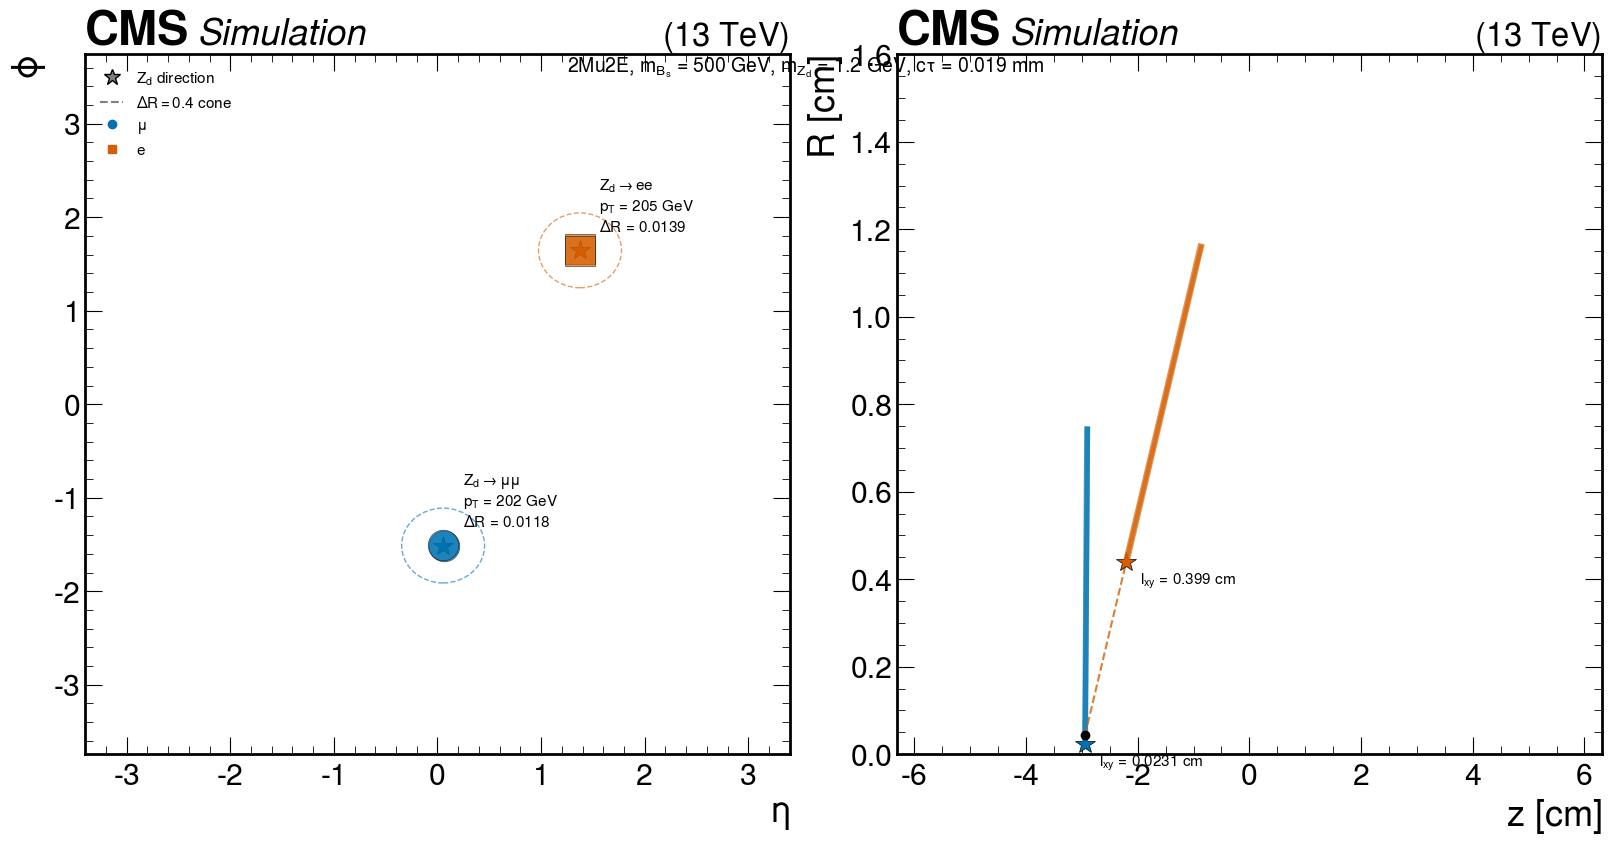

In [3]:
rec = display("2Mu2E_500GeV_1p2GeV_0p019mm", "signal_2mu2e_v10.yaml", "display_2mu2e_500_1p2")

**The analysis sweet spot.** Collimated muon pairs ($\Delta R \sim 0.02$) with decay vertices at the centimeter scale: beyond the beampipe, inside the pixel detector -- displaced enough to kill prompt backgrounds, close enough that tracking still works.

/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/display_4mu_200_1p2.pdf
4Mu_200GeV_1p2GeV_0p48mm: event index 497 (sample median max-lxy = 4.08 cm)
  Zd->mumu: pT = 107 GeV, lxy = 0.537 cm, daughter pT = [11.5, 95.9] GeV
  Zd->mumu: pT = 93 GeV, lxy = 4.08 cm, daughter pT = [55.1, 37.5] GeV


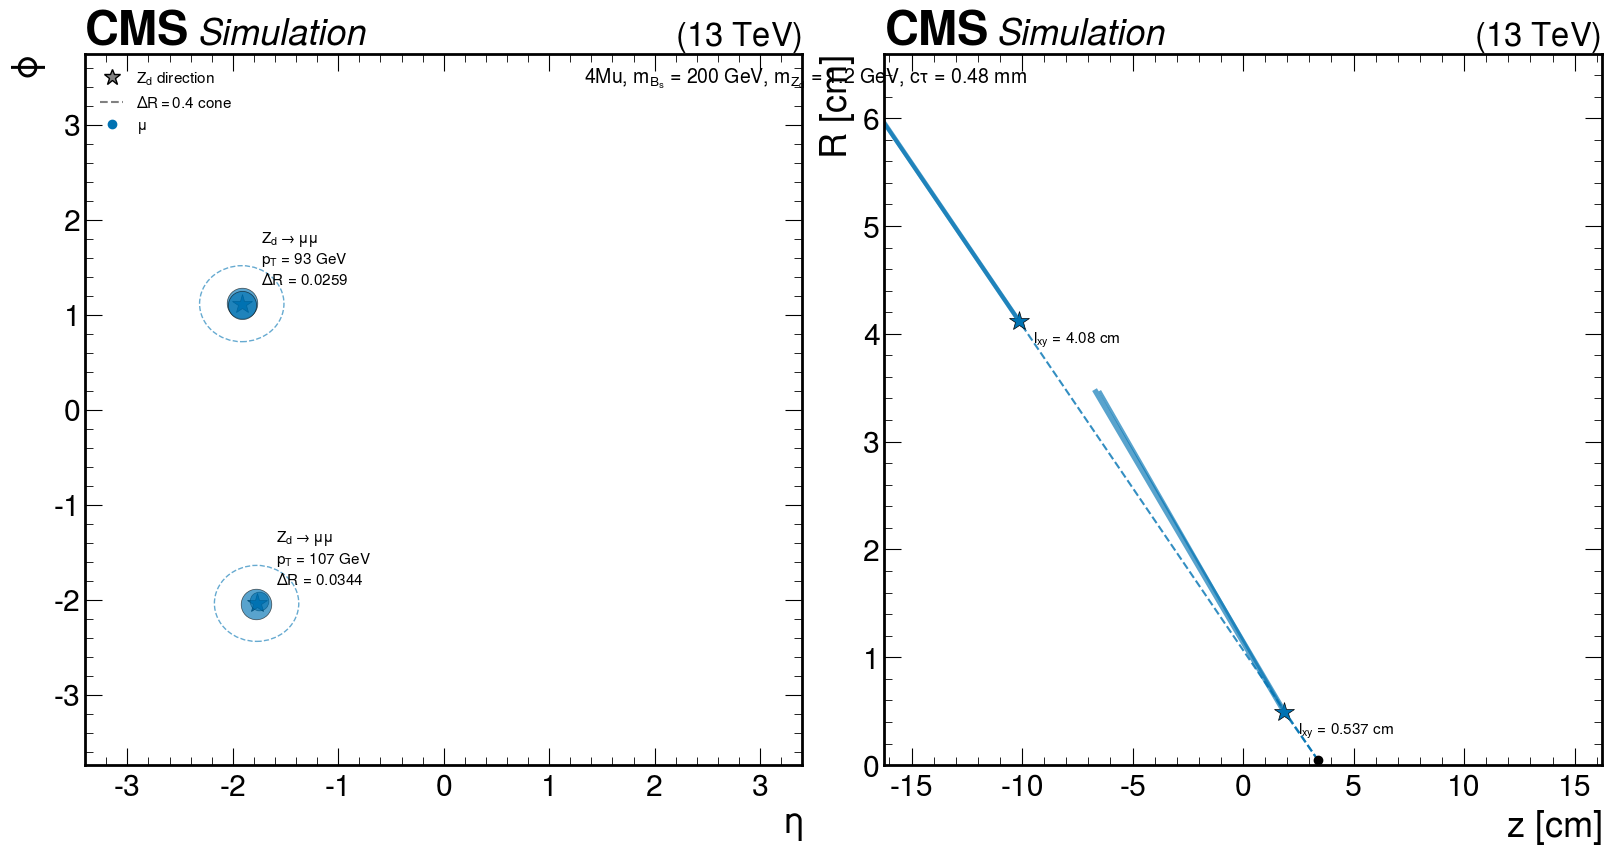

In [4]:
rec = display("4Mu_200GeV_1p2GeV_0p48mm", "signal_4mu_v10.yaml", "display_4mu_200_1p2")

**Extreme collimation.** At $m_{B_s} = 1000$ GeV each dark photon carries $p_T \sim 500$ GeV, and with $m_{Z_d} = 0.25$ GeV the pair opening angle is $\Delta R \sim 2m/p_T \sim 10^{-3}$ -- more than two orders of magnitude inside the clustering cone; only the annotation separates the two muons in the left panel. The boost also stretches the decay length to tens of centimeters despite $c\tau = 0.2$ mm.

/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/display_4mu_1000_0p25.pdf
4Mu_1000GeV_0p25GeV_0p2mm: event index 2821 (sample median max-lxy = 39.2 cm)
  Zd->mumu: pT = 297 GeV, lxy = 22.5 cm, daughter pT = [109.7, 186.8] GeV
  Zd->mumu: pT = 329 GeV, lxy = 39.3 cm, daughter pT = [123.5, 205.2] GeV


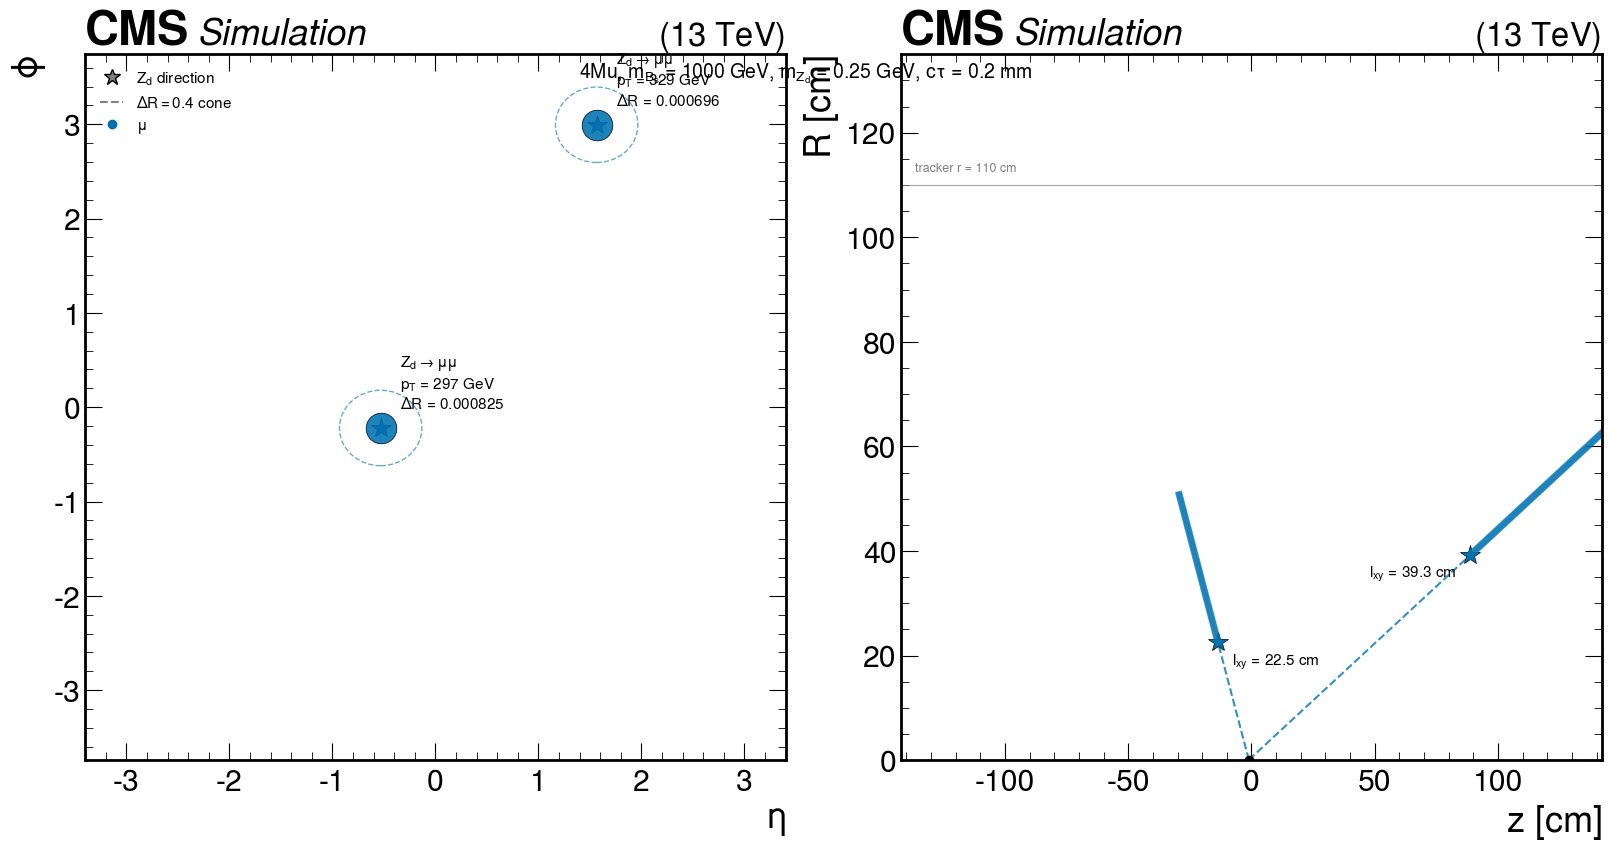

In [5]:
rec = display("4Mu_1000GeV_0p25GeV_0p2mm", "signal_4mu_v10.yaml", "display_4mu_1000_0p25")

**The wide, long-lived corner.** $m_{Z_d} = 5$ GeV against $p_T(Z_d) \sim 50$ GeV gives $\Delta R \sim 0.2$, an appreciable fraction of the cone size, and $c\tau = 200$ mm with $\beta\gamma \sim 10$ puts decay vertices at the meter scale -- beyond the tracker, where only the muon pair remains reconstructable (as DSA muons).

/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/display_2mu2e_100_5p0.pdf
2Mu2E_100GeV_5p0GeV_200mm: event index 702 (sample median max-lxy = 189 cm)
  Zd->mumu: pT = 44 GeV, lxy = 126 cm, daughter pT = [32.0, 11.9] GeV
  Zd->ee: pT = 57 GeV, lxy = 189 cm, daughter pT = [12.6, 44.7] GeV


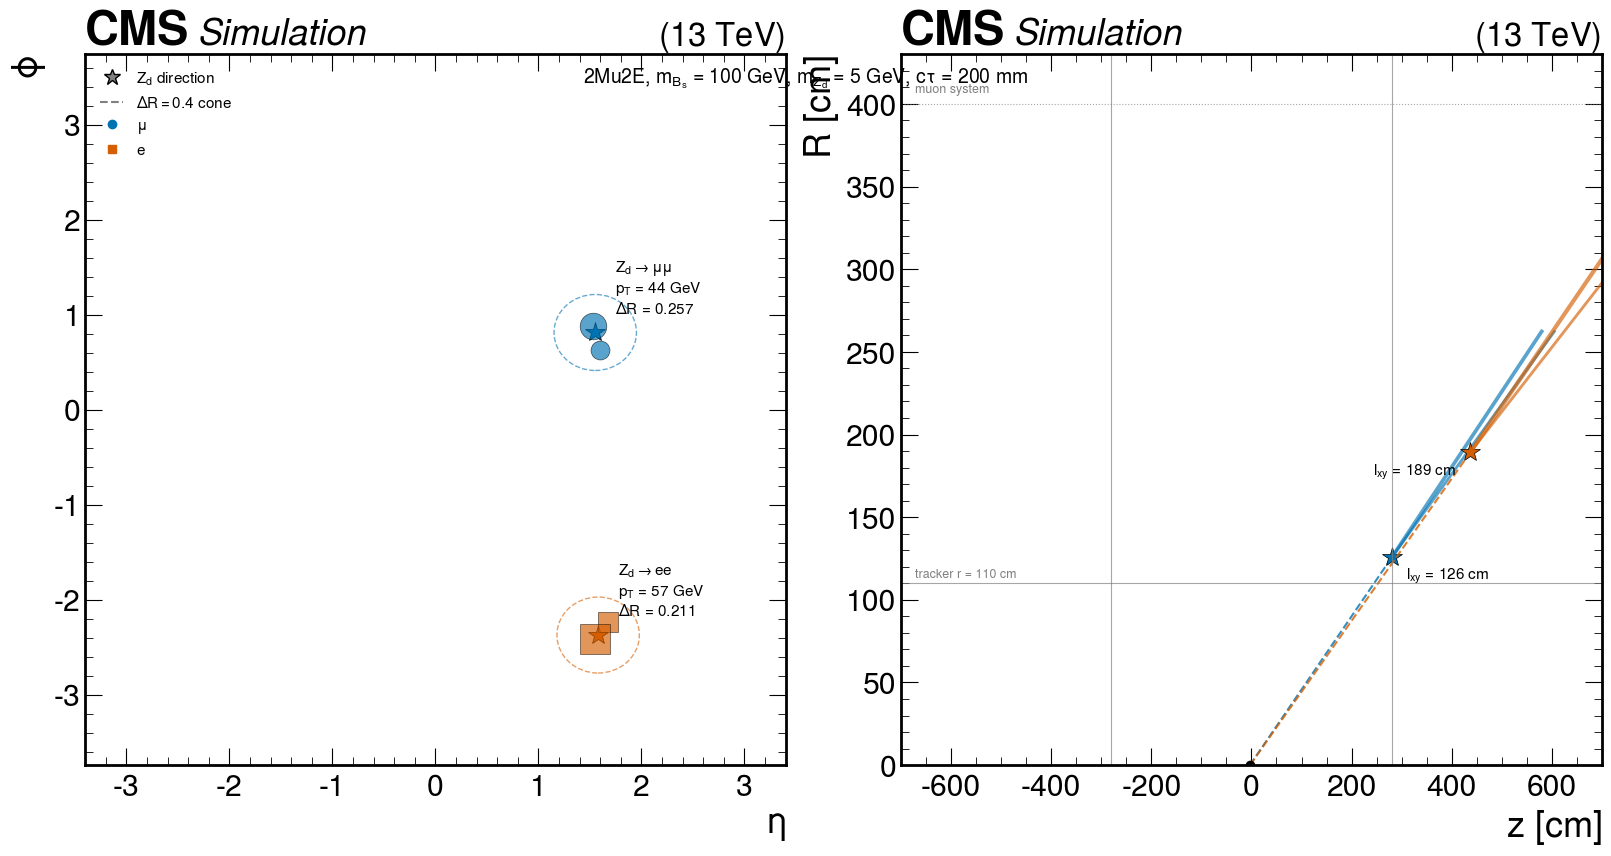

In [6]:
rec = display("2Mu2E_100GeV_5p0GeV_200mm", "signal_2mu2e_v10.yaml", "display_2mu2e_100_5p0")

Across the four corners the same three features recur: each dark photon's daughters stay inside a single $\Delta R = 0.4$ cone (collimation), the two cones sit at $\Delta\phi \approx \pi$ (back-to-back production), and the decay vertices sweep from the beamline to the muon system as $c\tau$ and boost vary (displacement). These are the features the lepton-jet definition, the displaced triggers, and the vertex-based selections are built around; the distributions behind each of them are shown in `final_state_anatomy_forAN.ipynb`.